In [1]:
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from src.transparentml.linear_models.linear_regression import LinearRegression
from src.transparentml.linear_models.sgd_regression import SGDRegression
from src.transparentml.linear_models.logistic_regression import LogisticRegression
from src.transparentml.tree.decision_tree import DecisionTree
from src.transparentml.neighbors.knn import KNN

In [2]:
X, y, true_coef = make_regression(
    n_samples=100,
    n_features=1,
    n_targets=1,
    noise=20,
    coef=True,
    random_state=0
)

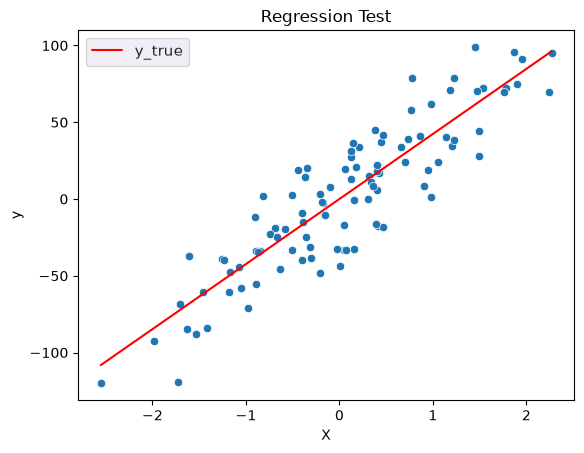

In [3]:
plt.title("Regression Test")

sns.set_theme(context="notebook", style="darkgrid")

sns.scatterplot(x=X[:, 0], y=y)

y_true_line = X[:, 0] * true_coef
sns.lineplot(x=X[:, 0], y=y_true_line, color="red", label="y_true")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [4]:
lr = LinearRegression()
lr.fit(X, y)

In [5]:
sgdr = SGDRegression(epochs=150)
sgdr.fit(X, y)

In [6]:
lr.weights

array([-1.62836365, 42.85335573])

In [7]:
sgdr.intercept_, sgdr.coef_

(np.float64(-1.1870882438142896), array([40.90208481]))

In [8]:
true_coef

array(42.38550486)

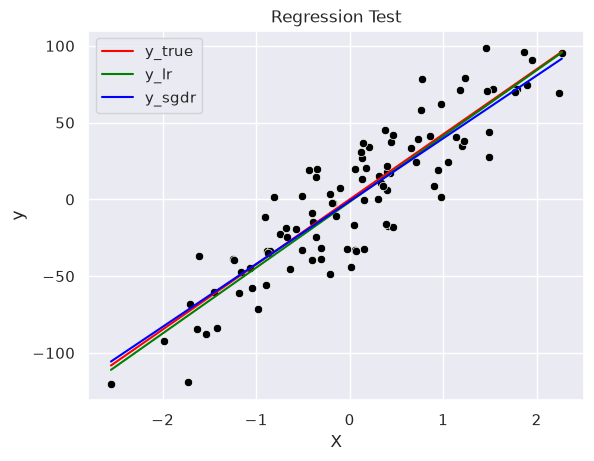

In [9]:
plt.title("Regression Test")

sns.set_theme(context="notebook", style="darkgrid")

sns.scatterplot(x=X[:, 0], y=y, color="black")

y_true_line = X[:, 0] * true_coef
y_pred_lr_line = lr.predict(X)
y_pred_sgdr_line = sgdr.predict(X)
sns.lineplot(x=X[:, 0], y=y_true_line, color="red", label="y_true")
sns.lineplot(x=X[:, 0], y=y_pred_lr_line, color="green", label="y_lr")
sns.lineplot(x=X[:, 0], y=y_pred_sgdr_line, color="blue", label="y_sgdr")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [10]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=0
)

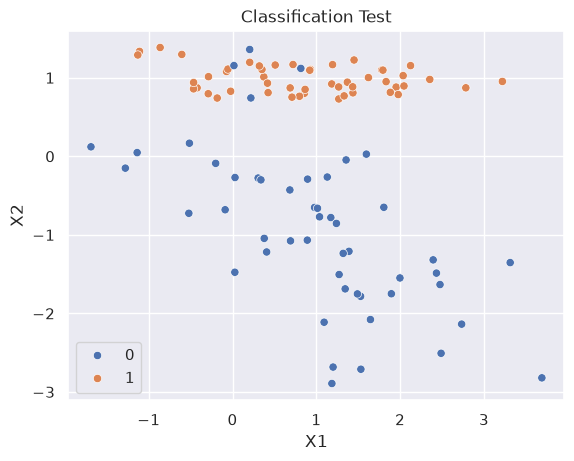

In [11]:
plt.title("Classification Test")

sns.set_theme(context="notebook", style="dark")

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [12]:
lgd = LogisticRegression(epochs=2000)
lgd.fit(X, y)

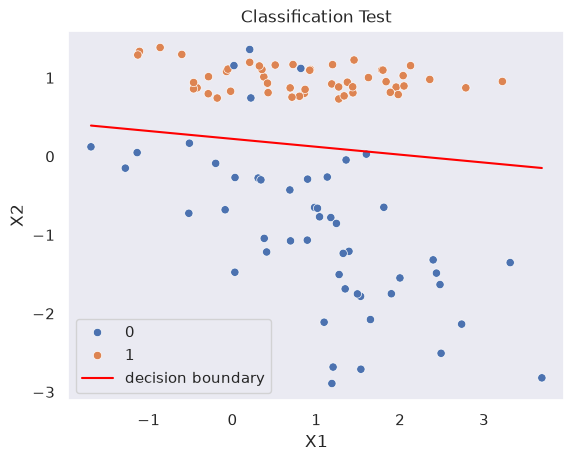

In [13]:
plt.title("Classification Test")
sns.set_theme(context="notebook", style="dark")

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2_boundary = -(lgd.coef_[0] * x1_range + lgd.intercept_) / lgd.coef_[1]

sns.lineplot(x=x1_range, y=x2_boundary, color="red", label="decision boundary")

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [14]:
dt = DecisionTree()
dt.fit(X, y)

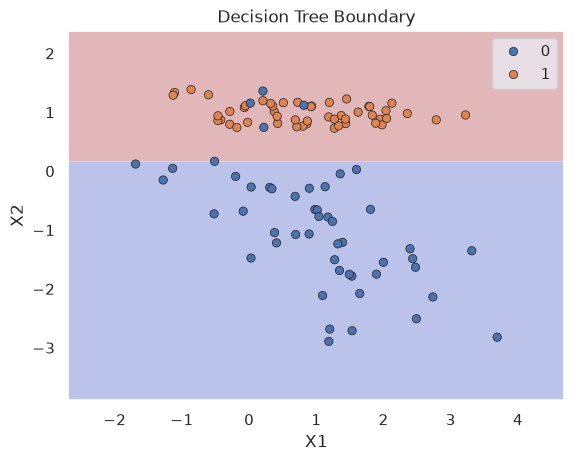

In [15]:
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)

grid_points = np.c_[xx1.ravel(), xx2.ravel()]
preds = dt.predict(grid_points).reshape(xx1.shape)

plt.contourf(xx1, xx2, preds, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="deep", edgecolor="k")

plt.title("Decision Tree Boundary")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [16]:
knn = KNN()
knn.fit(X, y)

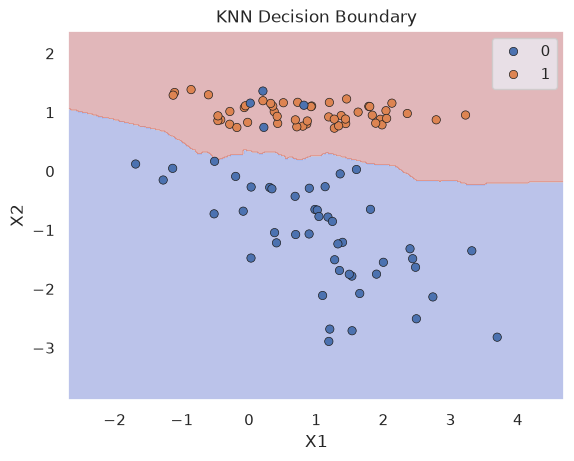

In [17]:
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)

grid_points = np.c_[xx1.ravel(), xx2.ravel()]
preds = knn.predict(grid_points).reshape(xx1.shape)

plt.contourf(xx1, xx2, preds, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="deep", edgecolor="k")

plt.title("KNN Decision Boundary")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()